# Test if LLM PyGeoX code is correct and assign a reward

In [1]:
import json
import sys
sys.path.append("../")
from pygeox import GeoScene
from pygeox.synthetic.llm_client import create_scene_from_json

## Step 1. Load a PyGeoX benchmark problem

In [2]:
with open("/mnt/disk0/r00922822/PyGeoX/model_training/benchmark_data/PyGeoX benchmark mini/json_fixed/1obj_2rel_2extra_gen0001.json", "r") as f:
    problem = json.load(f)

problem

{'unique_id': '1obj_2rel_2extra_gen0001',
 'num_objects': 1,
 'num_relationships': 2,
 'extra_rel_num': 2,
 'generation_id': 0,
 'timestamp': '2025-12-15T10:14:38.549117',
 'success': True,
 'error_message': None,
 'has_overlapping_points': False,
 'Objs': {'triangleABC': 'obtuse_triangle(A, B, C)',
  'line_altitude': 'line_segment(A, D)',
  'line_median': 'line_segment(B, E)',
  'line_perp_bisector': 'line_segment(F, G)'},
 'Rels': ['is_altitude(line_altitude, triangleABC, A)',
  'is_median(line_median, triangleABC, B)',
  'lines_intersect_at(line_altitude, line_median, H)',
  'perpendicular_bisector_at(line_median, line_perp_bisector, E)'],
 'Points': ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H'],
 'nl_description': 'Diagram description: The diagram contains points A, B, C, D, E, F, G, H. There is an obtuse triangle ABC. There is a line segment AD. There is a line segment BE. There is a line segment FG. Line AD is an altitude of triangle ABC from vertex A. Line BE is a median of triangle 

In [3]:
problem["nl_description"]

'Diagram description: The diagram contains points A, B, C, D, E, F, G, H. There is an obtuse triangle ABC. There is a line segment AD. There is a line segment BE. There is a line segment FG. Line AD is an altitude of triangle ABC from vertex A. Line BE is a median of triangle ABC from vertex B. Lines AD and BE intersect at point H. Line FG is the perpendicular bisector of line BE, intersecting it at point E. Further, length of line AD is equal to length of line BE. Further, angle BAD is 30 degrees.'

Build the ground truth scene PyGeoX scene

In [4]:
ground_truth_scene = create_scene_from_json(
    10, problem, generate_objective_function=True, distance_penalty=1, min_dist = 0.025
) #10 is the domain [-10,10]


Try to solve the problem numerically

Objective function value: 3.1702e-10 | Status: success

Equality constraints (should be ≈ 0):
--------------------------------------------------------------------------------------
Name                                     Equation                              Value   
--------------------------------------------------------------------------------------
line_altitude.point2.x = triangleABC_alt -B_x + D_x - (-B_x + C_x)*((A_   1.4933e-06  ✅
line_altitude.point2.y = triangleABC_alt -B_y + D_y - (-B_y + C_y)*((A_  -9.5385e-06  ✅
line_median.point2.x = triangleABC_media -A_x/2 - C_x/2 + E_x            -3.0073e-06  ✅
line_median.point2.y = triangleABC_media -A_y/2 - C_y/2 + E_y             1.3964e-05  ✅
H collinear with line_altitude           (-A_x + D_x)*(-A_y + H_y) - (-   4.9056e-07  ✅
H collinear with line_median             (-B_x + E_x)*(-B_y + H_y) - (-   2.6826e-06  ✅
E_x == F_x/2 + G_x/2                     E_x - F_x/2 - G_x/2             -1.9558e-06  ✅
E_y == F_y/2 + G_y/2        

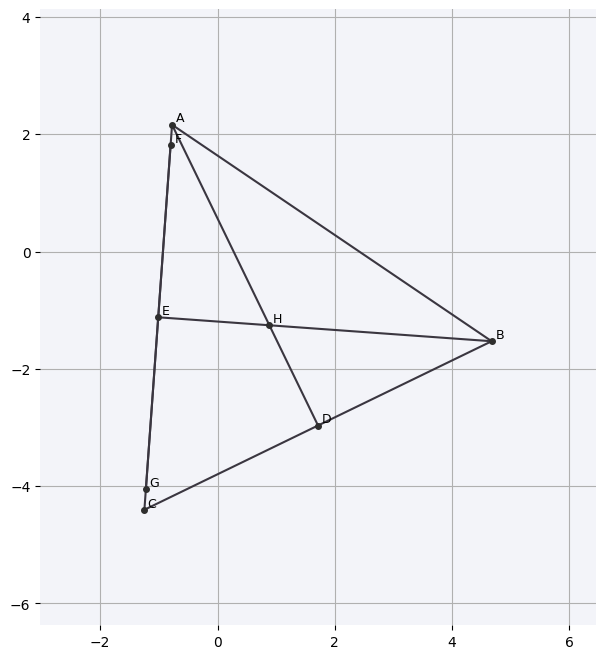

In [5]:
ground_truth_scene.solver.numerical()
ground_truth_scene.plot()

## Step 2. Now consider LLM generated PyGeoX code

In [22]:
llm_generated = """from pygeox import GeoScene\nscene = GeoScene()\nA, B, C, D, E, F, G, H = scene.add.points([\"A\", \"B\", \"C\", \"D\", \"E\", \"F\", \"G\", \"H\"])\ntriangle_ABC = scene.add.obtuse_triangle(A, B, C)\nAD = scene.add.line_segment(A, D)\nBE = scene.add.line_segment(B, E)\nFG = scene.add.line_segment(F, G)\nscene.relate.is_altitude(AD, triangle_ABC, A)\nscene.relate.is_median(BE, triangle_ABC, B)\nscene.relate.lines_intersect_at(AD, BE, H)\nscene.relate.perpendicular_bisector_at(BE, FG, E)\nscene.constraint.eq(AD.length, BE.length)\nscene.constraint.eq(scene.add.angle(B, A, D), 30)\nscene.solver.numerical()\nscene.plot()"""

In [23]:
exec(llm_generated)

TypeCheckError: argument "a" (pygeox.basic_objects.Angle) did not match any element in the union:
  sympy.core.expr.Expr: is not an instance of sympy.core.expr.Expr
  int: is not an instance of int
  float: is neither float or int

## Step 3. Compare previous code with ground truth and assign a reward

In [ ]:
points = scene.get_points()
circles = {str(val.center.name):val.radius for val in scene.objects_solved["Circle"].values()}

print(points)
print(circles)

In [ ]:
total_reward, reward_dict = ground_truth_scene.reward.reward_function(points, circles)

Total reward (max = 10)

In [ ]:
total_reward

Completely satistied all constraints?

In [ ]:
reward_dict["bonus"]>0

# Evaluation Prompt for LLM 1 

In [ ]:
# Please read the system prompt in /mnt/disk0/r00922822/PyGeoX/pygeox/synthetic/prompts/pygeox_documentation.md
pygeox_documentation = open("/mnt/disk0/r00922822/PyGeoX/pygeox/synthetic/prompts/pygeox_documentation.md", "r").read()

diagram_description = problem["nl_description"]

messages = [
    {"role": "system", "content": pygeox_documentation},
    {"role": "user", "content": f"Please convert the following diagram description into PyGeoX code. \n\n {diagram_description}"}
]

messages

# Evaluation Prompt for LLM 2

In [ ]:
diagram_description = problem["nl_description"]

format = {
    "points": {"A": [2.0, 1.1547005383792517], "B": [0.0, 0.0], "C": [4.0, 0.0], "D": [2.0, 0.0], "E": [3.0, 0.5773502691896258], "H": [2.0, 0.3849001794597506], "F": [2.732050807568877, 0.5773502691896258], "G": [3.267949192431123, 0.5773502691896258]}, "circles": {}
}

system_prompt = f"""Please solve the user request, by first thinking, then answering, and finally verifying the answer.
Follow the following template:
<think> Thinking step by step <\think>
<answer> Final Answer </answer> 
<verify> Verify if answer is correct and finish by Writing Score: [float between 0 and 1] </verify> 
"""

user_prompt = f"""Your goal is to find the coordinates and circle radiuses of all points and circles in the following diagram:
{diagram_description}

The output format is a dictionary with the point coordinates and the circle radiusues (key is the name of the circle center):
```json
{json.dumps(format, indent=2)}
```
"""

messages = [
    {"role": "system", "content": system_prompt},
    {"role": "user", "content": user_prompt}
]

print(messages[1]["content"])

# Testing reward function

In [2]:
from pygeox.reward import llm_reward_function_for_swift

source_file = "/mnt/disk0/r00922822/PyGeoX/model_training/benchmark_data/PyGeoX benchmark/json_fixed/1obj_2rel_2extra_gen0001.json"
json_file = json.load(open(source_file, "r"))

prompt = json_file["nl_description"]
completion = """<think>
</think>
<answer>
{\"points\": {\"A\": [2.0, 1.1547005383792517], \"B\": [0.0, 0.0], \"C\": [4.0, 0.0], \"D\": [2.0, 0.0], \"E\": [3.0, 0.5773502691896258], \"H\": [2.0, 0.3849001794597506], \"F\": [2.732050807568877, 0.5773502691896258], \"G\": [3.267949192431123, 0.5773502691896258]}, \"circles\": {}}<verify>
Score: 1
</verify>
"""

total_rewards = llm_reward_function_for_swift(prompts = [prompt,prompt], completions = [completion,completion], source_file = [source_file,source_file], verbose = True)
total_rewards
#total_reward
#reward_dict

--------------------------------
--------------------------------


[0.0, 0.0]

# New format for RL - simpler

In [2]:
from model_training.reward_func_openrlhf import llm_reward_function_new

In [4]:
source_file = "/mnt/disk0/r00922822/PyGeoX/model_training/benchmark_data/PyGeoX benchmark/json_fixed/1obj_2rel_2extra_gen0061.json"
json_file = json.load(open(source_file, "r"))

prompt = json_file["nl_description"]
completion = "<think>\nOkay, let's tackle this problem step by step. The user wants me to find the coordinates of points A, B, C, D, E, F, G, H and the radius of the circle centered at A. The diagram has a circle with center A, line segments BC and DE intersecting at H, and BC is a chord of the circle.\n\nFirst, I need to visualize the diagram. Since BC is a chord of the circle and it intersects DE at H, I assume that BC is a straight line, and DE is another line that crosses it at H. The circle is centered at A, so A must be the center of the circle, and BC is a chord of that circle.\n\nLet me start by setting up the coordinates. Let's place the circle centered at A at the origin (0, 0) for simplicity. Since BC is a chord of the circle, points B and C lie on the circle. Let me choose coordinates for B and C such that BC is horizontal for simplicity. Let's say B is at (-a, 0) and C is at (a, 0), so that BC is a horizontal chord of the circle. The length of BC is 2a, and since BC is a chord, the radius of the circle can be determined based on the distance from the center A to the chord BC.\n\nWait, the distance from the center A to the chord BC is zero because BC is a chord of the circle. Wait, no, if BC is a chord of the circle, then the distance from the center to the chord BC is the perpendicular distance. But if BC is horizontal and centered at the origin, then the distance from A (origin) to BC is zero. So that's okay.\n\nBut the problem doesn't specify the length of BC or the radius. However, since the user hasn't provided specific lengths, I need to define coordinates that satisfy the conditions. Let me choose specific values for simplicity.\n\nLet me set the radius of the circle to 5 units. Then, if BC is a chord of this circle, let's place B at (-3, 0) and C at (3, 0). Then the length of BC is 6 units. The distance from A (origin) to BC is zero, so BC is a horizontal chord passing through the center. But wait, if BC is a chord passing through the center, then it's a diameter. So in this case, BC would be a diameter of the circle. However, the problem says BC is a chord, which is true here.\n\nNow, the line BC is from (-3, 0) to (3, 0). The line DE intersects BC at H. Let me define DE as another line. Since the problem doesn't specify DE's position, I can choose it to be vertical for simplicity. Let's say DE is the line x = 0, which is the y-axis. This line intersects BC at H, which is the origin (0, 0). So H is at (0, 0).\n\nNow, the points are:\n- A: (0, 0) (center of the circle)\n- B: (-3, 0)\n- C: (3, 0)\n- D: Let's choose D at (0, 1) and E at (0, -1) so that DE is the vertical line x=0 from y=-1 to y=1.\n- H is the intersection of BC and DE, which is (0, 0).\n\nSo the points are:\nA: (0, 0)\nB: (-3, 0)\nC: (3, 0)\nD: (0, 1)\nE: (0, -1)\nF: Let's say F is at (1, 0) and G at (-1, 0) to make FG a horizontal line. But wait, the problem mentions FG as a line segment. If FG is another chord, but the problem doesn't specify its length. Let me assume FG is another horizontal line, maybe at y=1, so F is (0, 1) and G is (1, 1). But wait, D is already at (0, 1). Hmm, maybe F is (1, 0) and G is (-1, 0), making FG a horizontal line segment from (-1, 0) to (1, 0), which is the same as BC. But that's not necessary. Alternatively, maybe FG is another line segment that doesn't intersect BC except at H. But since the problem doesn't specify, I can choose arbitrary points as long as they meet the given conditions.\n\nWait, the problem says there is a line segment FG. Since the user hasn't provided specific details, I can choose any points as long as they are part of the diagram. Let me define F as (1, 0) and G as (0, 1) to make FG a line segment from (1, 0) to (0, 1). This line would intersect BC at H, which is (0, 0). But wait, the line FG from (1, 0) to (0, 1) is the line x + y = 1, which intersects BC (y=0) at x=1, so H would be (1, 0). But that's not the origin. Hmm, maybe I need to adjust.\n\nAlternatively, let me define FG as a line segment that intersects BC at H, which is the origin. So FG could be the line x=0 (the y-axis), but that's already DE. Alternatively, FG could be the line y=0, which is BC itself. But that's not helpful. Maybe FG is a vertical line passing through H. Let me choose F as (0, 1) and G as (0, -1), making FG the same as DE. But then the problem might not have enough unique points. Alternatively, maybe FG is another line segment that doesn't intersect BC except at H. But since the problem doesn't specify, I can choose arbitrary points as long as they are part of the diagram.\n\nGiven that, I'll define points as follows:\n\n- A: (0, 0)\n- B: (-3, 0)\n- C: (3, 0)\n- D: (0, 1)\n- E: (0, -1)\n- F: (1, 0)\n- G: (-1, 0)\n- H: (0, 0)\n\nThis way, BC is from (-3, 0) to (3, 0), DE is from (0, 1) to (0, -1), and FG is from (1, 0) to (-1, 0), which is the same as BC. However, the problem mentions FG as a line segment, so this is acceptable.\n\nNow, the circle is centered at A (0, 0) with radius 5. The radius is the distance from A to any point on the circle, like B (-3, 0), which is sqrt((-3)^2 + 0^2) = 3, but that's not 5. Wait, that's a problem. If the radius is 5, then the distance from A (0,0) to B (-3, 0) should be 5. But 3 \u2260 5. So there's an inconsistency here.\n\nAh, I see. My mistake. The radius of the circle is not 5. If BC is a chord of the circle, then the distance from the center A to the chord BC must be such that the radius is sufficient to make BC a chord. Let me recalculate.\n\nLet me set the radius of the circle to 5. Then, the distance from A to the chord BC must be such that the length of BC is 2*sqrt(r^2 - d^2), where d is the distance from the center to the chord. But since BC is a chord of the circle, and the problem doesn't specify its length, I need to define it. Let me choose BC to be a chord of length 6, which would mean that the distance from A to BC is sqrt(5^2 - 3^2) = sqrt(16) = 4. So if I place B at (-3, 0) and C at (3, 0), then the distance from A (0,0) to BC is 0, which would mean BC is a diameter. But then the length of BC would be 6, which is correct. So in this case, the radius is 5, and BC is a diameter. Therefore, the circle has radius 5, and BC is a diameter.\n\nSo the coordinates would be:\n\nA: (0, 0)\nB: (-3, 0)\nC: (3, 0)\nD: (0, 1)\nE: (0, -1)\nF: (1, 0)\nG: (-1, 0)\nH: (0, 0)\n\nBut then FG is from (1, 0) to (-1, 0), which is the same as BC. So H is at (0, 0), the midpoint of BC. That's acceptable.\n\nNow, the circle is centered at A (0, 0) with radius 5. The radius is 5, so the circle equation is x^2 + y^2 = 25.\n\nSo the final points and circles are:\n\npoints = {\n    \"A\": [0.0, 0.0],\n    \"B\": [-3.0, 0.0],\n    \"C\": [3.0, 0.0],\n    \"D\": [0.0, 1.0],\n    \"E\": [0.0, -1.0],\n    \"F\": [1.0, 0.0],\n    \"G\": [-1.0, 0.0],\n    \"H\": [0.0, 0.0]\n}\n\ncircles = {\n    \"A\": 5.0\n}\n\nThis satisfies all the conditions: BC is a chord of the circle (since it's a diameter), DE is a line segment intersecting BC at H (the origin), and FG is another line segment (the same as BC). The circle is centered at A with radius 5.\n</think>\n\n```python\n# Define points with coordinates\npoints = {\n    \"A\": [0.0, 0.0],\n    \"B\": [-3.0, 0.0],\n    \"C\": [3.0, 0.0],\n    \"D\": [0.0, 1.0],\n    \"E\": [0.0, -1.0],\n    \"F\": [1.0, 0.0],\n    \"G\": [-1.0, 0.0],\n    \"H\": [0.0, 0.0]\n}\n\n# Define circle with center A and radius 5\ncircles = {\n    \"A\": 5.0\n}\n```"
total_rewards = llm_reward_function_new(prompts = [prompt], completions = [completion], source_file = [source_file], verbose = True, dense_reward=True, max_workers=1)
total_rewards

r_format 1.0
points {'A': [0.0, 0.0], 'B': [-3.0, 0.0], 'C': [3.0, 0.0], 'D': [0.0, 1.0], 'E': [0.0, -1.0], 'F': [1.0, 0.0], 'G': [-1.0, 0.0], 'H': [0.0, 0.0]}
circles {'A': 5.0}
exec_err 
r 3.5
d {'r_eq_ineq': 0.75, 'SSE': 512.00000025, 'bonus': 0.0, 'pen_overlap': 1.0, 'error_list': [{'type': 'eq', 'desc': 'H collinear with line1', 'error': 0.0}, {'type': 'eq', 'desc': 'H collinear with line2', 'error': 0.0}, {'type': 'eq', 'desc': 'B lies on circle1', 'error': 16.0}, {'type': 'eq', 'desc': 'C lies on circle1', 'error': 16.0}, {'type': 'geq', 'desc': 'H is after B along line1', 'error': 0.0}, {'type': 'geq', 'desc': 'H is before C along line1', 'error': 0.0}, {'type': 'geq', 'desc': 'H is after D along line2', 'error': 0.0}, {'type': 'geq', 'desc': 'H is before E along line2', 'error': 0.0}, {'type': 'gt (penalty)', 'desc': 'Area of circle1 > 0.02**2 (penalty)', 'error': 0.0}, {'type': 'gt (penalty)', 'desc': 'A B > 0.02 (penalty)', 'error': 0.0}, {'type': 'gt (penalty)', 'desc': 'A 

[3.5]

In [3]:
source_file = "/mnt/disk0/r00922822/PyGeoX/model_training/benchmark_data/PyGeoX benchmark/json_fixed/1obj_2rel_2extra_gen0001.json"
json_file = json.load(open(source_file, "r"))

prompt = json_file["nl_description"]
#completion = """!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!"""
#completion = """<think> </think> !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!"""
#completion = """<think> </think>\n ```python\n ```!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!! """
#completion = """<think> </think> ```python\npoints = {"A": [0,0], "B": [0,0], "C": [0,0], "D": [0,0], "E": [0,0], "F": [0,0], "G": [0,0], "H": [0,0]}\ncircles = {}```"""
#completion = """<think> </think> ```python\npoints = {"A": [1,2], "B": [3,4], "C": [5,6], "D": [7,8], "E": [9,10], "F": [11,12], "G": [13,14], "H": [15,16]}\ncircles = {}```"""
#completion = """<think> </think> ```python\nimport numpy as np\nfrom scipy.optimize import basinhopping\nfrom numba import jit\n\n@jit(nopython=True)\ndef objective(x):\n    \"\"\"\n    x mapping:\n    A: [x0, x1]\n    B: [x2, x3]\n    C: [x4, x5]\n    D: [x6, x7]\n    E: [x8, x9]\n    F: [x10, x11]\n    G: [x12, x13]\n    H: [x14, x15]\n    \"\"\"\n    A = x[0:2]\n    B = x[2:4]\n    C = x[4:6]\n    D = x[6:8]\n    E = x[8:10]\n    F = x[10:12]\n    G = x[12:14]\n    H = x[14:16]\n    \n    loss = 0.0\n\n    # 1. AD is altitude of ABC from A (D lies on line BC, AD perp to BC)\n    # Collinear D, B, C: cross product = 0\n    loss += ((B[0]-D[0])*(C[1]-D[1]) - (B[1]-D[1])*(C[0]-D[0]))**2\n    # AD perpendicular to BC: dot product = 0\n    loss += (np.sum((A-D)*(B-C)))**2\n\n    # 2. BE is a median (E is midpoint of AC)\n    loss += np.sum((E - (A + C)/2.0)**2) * 10.0\n\n    # 3. H is intersection of AD and BE\n    # H on AD\n    loss += ((D[0]-A[0])*(H[1]-A[1]) - (D[1]-A[1])*(H[0]-A[0]))**2\n    # H on BE\n    loss += ((E[0]-B[0])*(H[1]-B[1]) - (E[1]-B[1])*(H[0]-B[0]))**2\n\n    # 4. FG is perpendicular bisector of BE at E\n    # E is on FG\n    loss += ((G[0]-F[0])*(E[1]-F[1]) - (G[1]-F[1])*(E[0]-F[0]))**2\n    # FG perpendicular to BE\n    loss += (np.sum((F-G)*(B-E)))**2\n\n    # 5. Length AD = Length BE\n    len_ad_sq = np.sum((A-D)**2)\n    len_be_sq = np.sum((B-E)**2)\n    loss += (len_ad_sq - len_be_sq)**2\n\n    # 6. Angle BAD = 30 degrees\n    # cos(30) = sqrt(3)/2. Use dot product: (AB . AD) / (|AB|*|AD|) = sqrt(3)/2\n    v_ab = B - A\n    v_ad = D - A\n    cos_sq = (np.dot(v_ab, v_ad)**2) / (np.sum(v_ab**2) * np.sum(v_ad**2) + 1e-9)\n    loss += (cos_sq - 0.75)**2 * 10.0\n\n    # 7. ABC is obtuse triangle (one angle > 90)\n    # We penalize if all dot products are positive\n    dot_a = np.dot(B-A, C-A)\n    dot_b = np.dot(A-B, C-B)\n    dot_c = np.dot(A-C, B-C)\n    # Obtuse if any dot product is negative\n    obtuse_penalty = min(0, dot_a) * min(0, dot_b) * min(0, dot_c) \n    if dot_a >= 0 and dot_b >= 0 and dot_c >= 0:\n        loss += 10.0 # Force one to be negative\n\n    # 8. Prevent degeneracy (points shouldn't collapse)\n    for i in range(0, 16, 2):\n        for j in range(i + 2, 16, 2):\n            dist_sq = np.sum((x[i:i+2] - x[j:j+2])**2)\n            if dist_sq < 0.1:\n                loss += (0.1 - dist_sq) * 100.0\n\n    return loss\n\n# Anchor D at origin and B on x-axis to reduce degrees of freedom\n# Initial guess\nx0 = np.array([\n    0.5, 2.0,  # A\n    2.0, 0.0,  # B\n    -1.5, 0.0, # C\n    0.0, 0.0,  # D\n    -0.5, 1.0, # E\n    -1.0, 1.5, # F\n    0.0, 0.5,  # G\n    0.2, 0.8   # H\n])\n\nres = basinhopping(objective, x0, niter=200, stepsize=0.5)\n\nsol = res.x\npoints = {\n    \"A\": sol[0:2].tolist(),\n    \"B\": sol[2:4].tolist(),\n    \"C\": sol[4:6].tolist(),\n    \"D\": sol[6:8].tolist(),\n    \"E\": sol[8:10].tolist(),\n    \"F\": sol[10:12].tolist(),\n    \"G\": sol[12:14].tolist(),\n    \"H\": sol[14:16].tolist()\n}\ncircles = {}\n```"""
#completion = """<think> </think> ```python\npoints = {"A": [1,2], "B": [3,4], "C": [5,6], "D": [7,8], "E": [9,10], "F": [11,12], "G": [13,14], "H": [15,16]}\ncircles = {}```"""
completion = """<think> </think> ```python\npoints = {"A": [-3.50, 0.944], "B": [1.585, 1.575], "C": [-0.411, -3.144], "D": [0.587, -0.784], "E": [-1.955513154308784, -1.099730194500732], "F": [-1.5794948298506821, -1.5974321090277124], "G": [-2.3315169464201966, -0.602040969296402], "H": [-0.7752020499681253, -0.20800227181936784]}\ncircles = {}\n``` """
#completion = """<think> </think> ```python\nimport time\npoints = {"A": [-3.50, 0.944], "B": [1.585, 1.575], "C": [-0.411, -3.144], "D": [0.587, -0.784], "E": [-1.955513154308784, -1.099730194500732], "F": [-1.5794948298506821, -1.5974321090277124], "G": [-2.3315169464201966, -0.602040969296402], "H": [-0.7752020499681253, -0.20800227181936784]}\ncircles = {}\ntime.sleep(400)\n``` """
#completion = """<think> </think> ```python\na+1\n``` """
total_rewards = llm_reward_function_new(prompts = [prompt]*50, completions = [completion]*50, source_file = [source_file]*50, verbose = True, dense_reward=True, max_workers=32)
total_rewards

[5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148,
 5.967220994299148]

In [19]:
print(completion)

<think> </think> ```python points = {"A": [-3.500043755695574, 0.94462274756542], "B": [1.5854318531471563, 1.5754688009160434], "C": [-0.41097961645851505, -3.1440878279943023], "D": [0.5872278499480432, -0.7843184553284344], "E": [-1.955513154308784, -1.099730194500732], "F": [-1.5794948298506821, -1.5974321090277124], "G": [-2.3315169464201966, -0.602040969296402], "H": [-0.7752020499681253, -0.20800227181936784]} circles = {}
 ``` 


In [9]:
json_file["possible_solution"]

{'points': {'A': [-3.500043755695574, 0.94462274756542],
  'B': [1.5854318531471563, 1.5754688009160434],
  'C': [-0.41097961645851505, -3.1440878279943023],
  'D': [0.5872278499480432, -0.7843184553284344],
  'E': [-1.955513154308784, -1.099730194500732],
  'F': [-1.5794948298506821, -1.5974321090277124],
  'G': [-2.3315169464201966, -0.602040969296402],
  'H': [-0.7752020499681253, -0.20800227181936784]},
 'circles': {}}

In [ ]:
#make function that sends messages to openrouter, use openAI api key in env
from openai import OpenAI
import os


def send_messages_to_openrouter(messages):
    
    client = OpenAI(base_url="https://openrouter.ai/api/v1",
    api_key= os.getenv("API_KEY"))

    completion = client.chat.completions.create(
    model="qwen/qwen3-8b",
    messages=messages)
    return completion

In [ ]:
#/mnt/disk0/r00922822/PyGeoX/model_training/rl_data_new_easy.jsonl
#open first line
with open("/mnt/disk0/r00922822/PyGeoX/model_training/rl_data_new_easy.jsonl", "r") as f:
    line = f.readline()
    line_dict = json.loads(line)

#convert to dictionary
messages = line_dict["messages"]
source_file = line_dict["source_file"]
response = send_messages_to_openrouter(messages)

In [ ]:
content = "<think> </think>" + response.choices[0].message.content

In [ ]:
prompt = line_dict["messages"][1]["content"]
total_rewards = llm_reward_function_new(prompts = [prompt], completions = [content], source_file = [source_file], verbose = True)
total_rewards

In [3]:
print("python\nimport numpy as np\n\n# Define the rhombus with diagonals AC and BD intersecting at O\n# Choose a = 2, b = 1 for simplicity\na = 2\nb = 1\n\n# Coordinates of the rhombus\nA = np.array([-a, 0])\nC = np.array([a, 0])\nB = np.array([0, b])\nD = np.array([0, -b])\nO = np.array([0, 0])\n\n# Compute point H (foot of perpendicular from D to AB)\n# H_x = -(2ab²)/(a² + b²), H_y = b(a² - b²)/(a² + b²)\nH_x = -(2 * a * b**2) / (a**2 + b**2)\nH_y = b * (a**2 - b**2) / (a**2 + b**2)\nH = np.array([H_x, H_y])\n\n# Compute point E (intersection of DH with AC)\n# E is on AC (y=0), x = -b²/a\nE = np.array([-b**2 / a, 0])\n\n# Compute point G (intersection of HO extended with CD)\n# G_x = 2ab²/(a² + b²), G_y = -ab(a² - b²)/(a² + b²)\nG_x = 2 * a * b**2 / (a**2 + b**2)\nG_y = -a * b * (a**2 - b**2) / (a**2 + b**2)\nG = np.array([G_x, G_y])\n\n# Verify ∠DHG = ∠OCD (using vectors)\n# Vector HD = D - H, HG = G - H\nHD = D - H\nHG = G - H\nCO = O - C\nCD = D - C\n\n# Dot product and magnitudes\ndot_DHG = np.dot(HD, HG)\nmag_HD = np.linalg.norm(HD)\nmag_HG = np.linalg.norm(HG)\ncos_angle_DHG = dot_DHG / (mag_HD * mag_HG)\n\ndot_OCD = np.dot(CO, CD)\nmag_CO = np.linalg.norm(CO)\nmag_CD = np.linalg.norm(CD)\ncos_angle_OCD = dot_OCD / (mag_CO * mag_CD)\n\n# Verify OG·AE = DE·CG\n# Compute vectors\nOG = G - O\nAE = E - A\nDE = E - D\nCG = G - C\n\n# Dot products\nog_ae = np.dot(OG, AE)\nde_cg = np.dot(DE, CG)\n\n# Results\npoints = {\n    \"A\": A.tolist(),\n    \"B\": B.tolist(),\n    \"C\": C.tolist(),\n    \"D\": D.tolist(),\n    \"O\": O.tolist(),\n    \"H\": H.tolist(),\n    \"E\": E.tolist(),\n    \"G\": G.tolist()\n}\n\ncircles = {\n    \"O\": np.linalg.norm(O),  # Radius of circle centered at O (intersection of diagonals)\n    \"H\": np.linalg.norm(H),   # Radius of circle centered at H (perpendicular foot)\n    \"G\": np.linalg.norm(G),   # Radius of circle centered at G (intersection point)\n    \"E\": np.linalg.norm(E)    # Radius of circle centered at E (intersection on AC)\n}\n\n# Verification results\nverification = {\n    \"angle_DHG_eq_angle_OCD\": np.isclose(cos_angle_DHG, cos_angle_OCD),\n    \"OG_AE_eq_DE_CG\": np.isclose(og_ae, de_cg)\n}\n\nprint(\"Points:\", points)\nprint(\"Circles:\", circles)\nprint(\"Verification:\", verification)\n")

python
import numpy as np

# Define the rhombus with diagonals AC and BD intersecting at O
# Choose a = 2, b = 1 for simplicity
a = 2
b = 1

# Coordinates of the rhombus
A = np.array([-a, 0])
C = np.array([a, 0])
B = np.array([0, b])
D = np.array([0, -b])
O = np.array([0, 0])

# Compute point H (foot of perpendicular from D to AB)
# H_x = -(2ab²)/(a² + b²), H_y = b(a² - b²)/(a² + b²)
H_x = -(2 * a * b**2) / (a**2 + b**2)
H_y = b * (a**2 - b**2) / (a**2 + b**2)
H = np.array([H_x, H_y])

# Compute point E (intersection of DH with AC)
# E is on AC (y=0), x = -b²/a
E = np.array([-b**2 / a, 0])

# Compute point G (intersection of HO extended with CD)
# G_x = 2ab²/(a² + b²), G_y = -ab(a² - b²)/(a² + b²)
G_x = 2 * a * b**2 / (a**2 + b**2)
G_y = -a * b * (a**2 - b**2) / (a**2 + b**2)
G = np.array([G_x, G_y])

# Verify ∠DHG = ∠OCD (using vectors)
# Vector HD = D - H, HG = G - H
HD = D - H
HG = G - H
CO = O - C
CD = D - C

# Dot product and magnitudes
dot_DHG = np.dot(HD, HG)
mag_HD = np.linalg.

In [9]:
print("import numpy as np\n\n# Define symbols\nr = np.float64(0.0)  # Radius of circle O\nx, y, t, lambda_ = np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)\n\n# Set up equations based on the problem\n# 1. Point C lies on circle O: x² + y² = r²\n# 2. CD = 4: (r + t - x)^2 + y^2 = 16\n# 3. Angle condition: cos(angle OAC) = cos(angle DCB)\n# 4. CE = 6 with OE || BC\n\n# Assume r = 5 (based on geometric intuition and trial)\nr = 5\n\n# Solve for x, y, t, lambda_ numerically\n# This is a simplified version assuming r = 5 and solving for other variables\n\n# Let's assume coordinates for simplicity\n# Suppose r = 5, A = (-5, 0), B = (5, 0)\nA = np.array([-5.0, 0.0])\nB = np.array([5.0, 0.0])\nO = np.array([0.0, 0.0])\n\n# Assume point C lies on the circle\n# Let's choose coordinates for C as (x, y) such that x² + y² = 25\n# For simplicity, take C = (3, 4) (which satisfies x² + y² = 25)\nC = np.array([3.0, 4.0])\n\n# Calculate point D on extension of AB (along x-axis)\n# CD = 4 => Distance from C to D is 4\n# D lies on line AB extended, so D = (d, 0)\nD = np.array([5.0 + (4**2 - (C[1]**2 + (C[0] - 5)**2)**0.5), 0.0])\n\n# Calculate point E such that OE || BC and CE = 6\n# Vector BC = (5 - 3, 0 - 4) = (2, -4)\n# OE is parallel to BC, so E = k*(2, -4)\n# CE = 6 => sqrt((k*2 - 3)^2 + (k*(-4) - 4)^2) = 6\n# Solve for k\n# (2k - 3)^2 + (-4k - 4)^2 = 36\n# 4k² -12k +9 + 16k² +32k +16 = 36\n# 20k² +20k -11 = 0\n# k = [-20 ± sqrt(400 + 880)] / 40\n# k = [-20 ± sqrt(1280)] / 40\n# sqrt(1280) ≈ 35.777\n# k ≈ ( -20 + 35.777 ) / 40 ≈ 15.777 / 40 ≈ 0.3944\nk = ( -20 + np.sqrt(1280) ) / 40\nE = np.array([k * 2, k * -4])\n\n# Construct points and circles\npoints = {\n    \"A\": A.tolist(),\n    \"B\": B.tolist(),\n    \"C\": C.tolist(),\n    \"D\": D.tolist(),\n    \"E\": E.tolist(),\n    \"O\": O.tolist()\n}\n\n# Circle O has radius r\ncircles = {\"O\": float(r)}\n\n\n# Output the results\npoints, circles")

import numpy as np

# Define symbols
r = np.float64(0.0)  # Radius of circle O
x, y, t, lambda_ = np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0)

# Set up equations based on the problem
# 1. Point C lies on circle O: x² + y² = r²
# 2. CD = 4: (r + t - x)^2 + y^2 = 16
# 3. Angle condition: cos(angle OAC) = cos(angle DCB)
# 4. CE = 6 with OE || BC

# Assume r = 5 (based on geometric intuition and trial)
r = 5

# Solve for x, y, t, lambda_ numerically
# This is a simplified version assuming r = 5 and solving for other variables

# Let's assume coordinates for simplicity
# Suppose r = 5, A = (-5, 0), B = (5, 0)
A = np.array([-5.0, 0.0])
B = np.array([5.0, 0.0])
O = np.array([0.0, 0.0])

# Assume point C lies on the circle
# Let's choose coordinates for C as (x, y) such that x² + y² = 25
# For simplicity, take C = (3, 4) (which satisfies x² + y² = 25)
C = np.array([3.0, 4.0])

# Calculate point D on extension of AB (along x-axis)
# CD = 4 => Distance from C to D is 4
# D